In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===========================
#  ROBUST DATA LOADING
# ===========================
downloads = os.path.join(os.path.expanduser("~"), "Downloads")
filename = os.path.join(downloads, "maser_N1.npz")


print(f"Loading simulation data from: {filename}")
data = np.load(filename)
print("Variables in archive:", data.files)

# Extract pump parameter
nh = data["nh_values"]

# Extract Observables 
navg     = data["navg_numerical"]
navg_an  = data["navg_analytical"]
power    = data["power_numerical"]
power_an = data["power_analytical"]
g2       = data["g2_numerical"]
g2_an    = data["g2_analytical"]
gain     = data["gain"]
thresholds = data["thresholds"]

# Scalars
kappa   = float(data["kappa"])
nc      = float(data["nc"])
gamma_h = float(data["gamma_h"])
gamma_c = float(data["gamma_c"])
g_coup  = float(data["g"])

# Calculate A, Ab, B analytically 
Gamma = gamma_h * nh + gamma_c * nc
Phi   = 3.0 * nh * nc + nh + nc
Psi   = (gamma_h * (2.0 * nh + 1.0) + gamma_c * (2.0 * nc + 1.0)) / (gamma_h * gamma_c)

A     = 4.0 * g_coup**2 * nh * (nc + 1.0) / (Gamma * Phi)
Ab    = 4.0 * g_coup**2 * nc * (nh + 1.0) / (Gamma * Phi)
B     = A * (4.0 * g_coup**2 * Psi) / (Gamma * Phi)

# Ensure all arrays are sorted by nh
idx = np.argsort(nh)
nh       = nh[idx]
navg     = navg[idx]
navg_an  = navg_an[idx]
power    = power[idx]
power_an = power_an[idx]
g2       = g2[idx]
g2_an    = g2_an[idx]
gain     = gain[idx]
A        = A[idx]
Ab       = Ab[idx]
B        = B[idx]

th1 = thresholds[0]
th2 = thresholds[1]

print("\n" + "=" * 60)
print(f"Number of pump points  : {len(nh)}")
print(f"Cold bath occupation nc: {nc}")
print(f"Turn-on threshold nh,1*: {th1:.5f}")
print(f"Quenching threshold nh,2*: {th2:.5f}")
print(f"Max photon number <n>  : {np.nanmax(navg):.4f} (QuTiP), {np.nanmax(navg_an):.4f} (Analytic)")
print("=" * 60 + "\n")

Loading simulation data from: /Users/gourabbhanja/Downloads/maser_N1.npz
Variables in archive: ['nh_values', 'navg_numerical', 'navg_analytical', 'power_numerical', 'power_analytical', 'g2_numerical', 'g2_analytical', 'gain', 'thresholds', 'kappa', 'g', 'gamma_h', 'gamma_c', 'nc']

Number of pump points  : 120
Cold bath occupation nc: 0.05
Turn-on threshold nh,1*: 0.05044
Quenching threshold nh,2*: 21.16043
Max photon number <n>  : 6.3408 (QuTiP), 10.0836 (Analytic)



/var/folders/mz/8z6t7nxj1rzg2jvg9_6hk8km0000gn/T/ipykernel_59360/3374464590.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


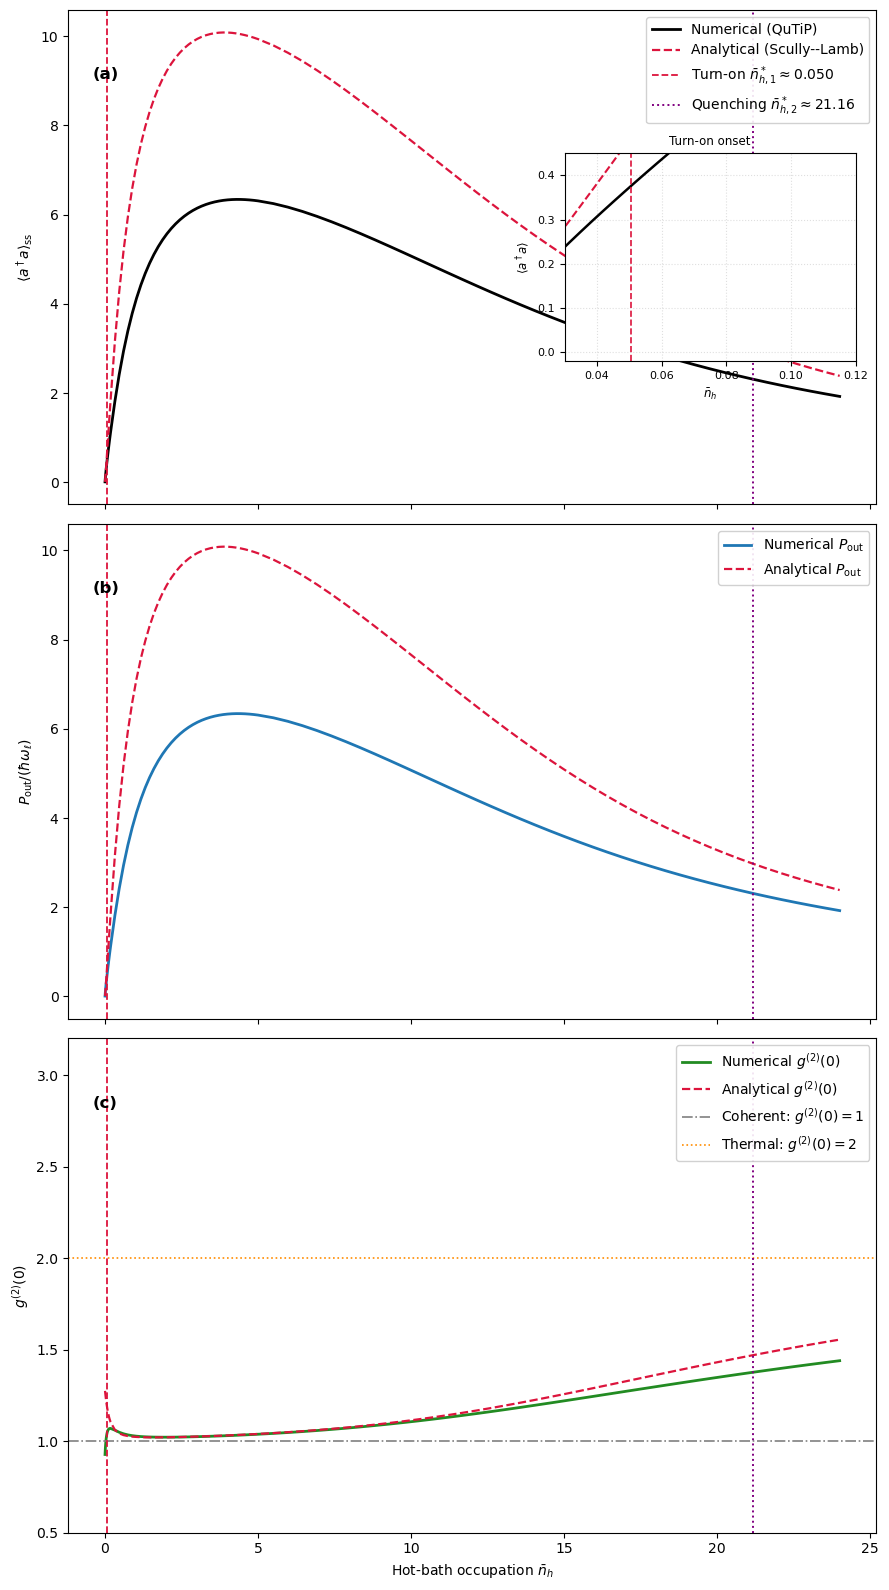

In [31]:
# ======================================
# FIGURE 1: PRIMARY MASING OBSERVABLES 
# ======================================
fig1, axes1 = plt.subplots(3, 1, figsize=(9, 16), sharex=True)

# ----------------- (a) Steady-state photon number <a†a> -----------------
ax1 = axes1[0]
ax1.plot(nh, navg, color="black", lw=2, label=r"Numerical (QuTiP)")
if navg_an is not None:
    ax1.plot(nh, navg_an, color="crimson", ls="--", lw=1.6, label=r"Analytical (Scully--Lamb)")

if np.isfinite(th1):
    ax1.axvline(th1, color="crimson", ls="--", lw=1.3, label=rf"Turn-on $\bar{{n}}_{{h,1}}^* \approx {th1:.3f}$")
if np.isfinite(th2):
    ax1.axvline(th2, color="purple", ls=":", lw=1.4, label=rf"Quenching $\bar{{n}}_{{h,2}}^* \approx {th2:.2f}$")

ax1.set_ylabel(r"$\langle a^\dagger a\rangle_{\rm ss}$")
ax1.text(0.03, 0.86, "(a)", transform=ax1.transAxes, fontweight="bold", fontsize=12)
ax1.legend(loc="upper right", frameon=True, framealpha=0.9)


# --- Inset: Zoom-in on the sharp turn-on threshold ---
ax_ins = inset_axes(ax1, width="36%", height="42%", loc="center right", borderpad=1.5)
ax_ins.plot(nh, navg, color="black", lw=1.8)
if navg_an is not None:
    ax_ins.plot(nh, navg_an, color="crimson", ls="--", lw=1.5)
ax_ins.axvline(th1, color="crimson", ls="--", lw=1.2)
ax_ins.set_xlim(0.03, 0.12)
ax_ins.set_ylim(-0.02, 0.45)
ax_ins.set_xlabel(r"$\bar{n}_h$", fontsize=8.5)
ax_ins.set_ylabel(r"$\langle a^\dagger a\rangle$", fontsize=8.5)
ax_ins.tick_params(axis='both', which='major', labelsize=8)
ax_ins.grid(True, ls=":", alpha=0.4)
ax_ins.set_title("Turn-on onset", fontsize=8.5)

# ----------------- (b) Cavity Output Power P_out -----------------------
ax2 = axes1[1]
ax2.plot(nh, power, color="tab:blue", lw=2, label=r"Numerical $P_{\rm out}$")
if power_an is not None:
    ax2.plot(nh, power_an, color="crimson", ls="--", lw=1.6, label=r"Analytical $P_{\rm out}$")
if np.isfinite(th1): ax2.axvline(th1, color="crimson", ls="--", lw=1.3)
if np.isfinite(th2): ax2.axvline(th2, color="purple", ls=":", lw=1.4)

ax2.set_ylabel(r"$P_{\rm out} / (\hbar\omega_\ell)$")
ax2.text(0.03, 0.86, "(b)", transform=ax2.transAxes, fontweight="bold", fontsize=12)
ax2.legend(loc="upper right", frameon=True, framealpha=0.9)


# ----------------- (c) Second-order correlation g^(2)(0) ----------------
ax3 = axes1[2]
ax3.plot(nh, g2, color="forestgreen", lw=2, label=r"Numerical $g^{(2)}(0)$")
if g2_an is not None:
    ax3.plot(nh, g2_an, color="crimson", ls="--", lw=1.6, label=r"Analytical $g^{(2)}(0)$")

ax3.axhline(1.0, color="gray", ls="-.", lw=1.2, label=r"Coherent: $g^{(2)}(0)=1$")
ax3.axhline(2.0, color="darkorange", ls=":", lw=1.2, label=r"Thermal: $g^{(2)}(0)=2$")
if np.isfinite(th1): ax3.axvline(th1, color="crimson", ls="--", lw=1.3)
if np.isfinite(th2): ax3.axvline(th2, color="purple", ls=":", lw=1.4)

ax3.set_xlabel(r"Hot-bath occupation $\bar{n}_h$")
ax3.set_ylabel(r"$g^{(2)}(0)$")
ax3.set_ylim(0.5, 3.2)
ax3.text(0.03, 0.86, "(c)", transform=ax3.transAxes, fontweight="bold", fontsize=12)
ax3.legend(loc="upper right", frameon=True, framealpha=0.9)

fig1.tight_layout()
plt.show()

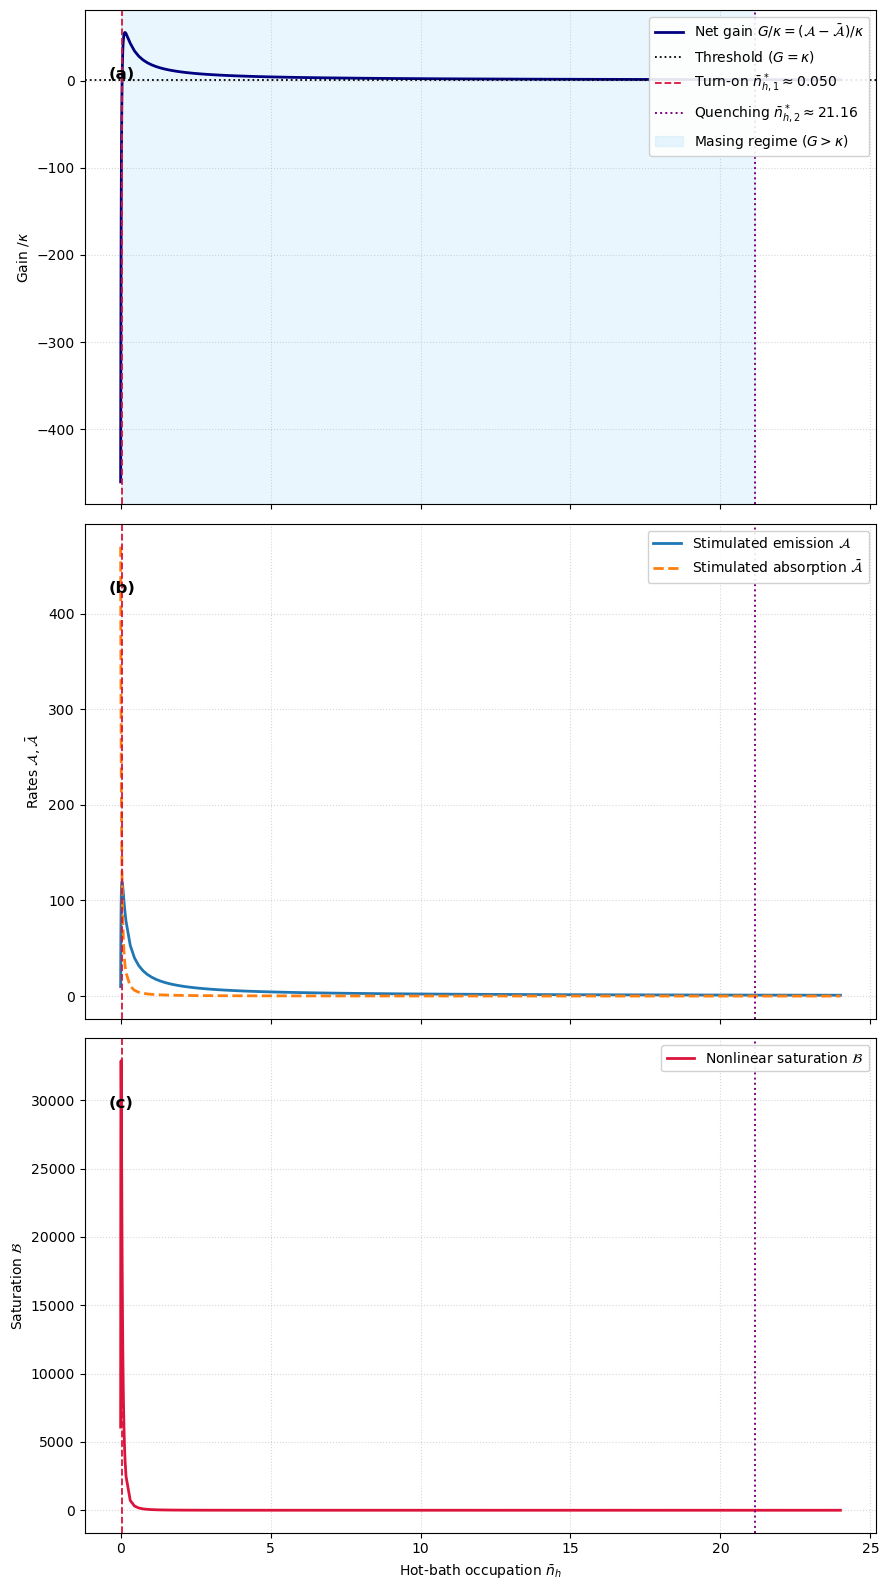

In [32]:
# =======================================================
# FIGURE 2: SCULLY–LAMB MICROSCOPIC PARAMETERS & GAIN
# =======================================================
fig2, axes2 = plt.subplots(3, 1, figsize=(9, 16), sharex=True)

# ----------------- (a) Net Gain G/kappa vs threshold --------------------
ax_g = axes2[0]
ax_g.plot(nh, gain / kappa, color="navy", lw=2, label=r"Net gain $G/\kappa = (\mathcal{A} - \bar{\mathcal{A}})/\kappa$")
ax_g.axhline(1.0, color="black", ls=":", lw=1.3, label=r"Threshold ($G=\kappa$)")
if np.isfinite(th1):
    ax_g.axvline(th1, color="crimson", ls="--", lw=1.3, label=rf"Turn-on $\bar{{n}}_{{h,1}}^* \approx {th1:.3f}$")
if np.isfinite(th2):
    ax_g.axvline(th2, color="purple", ls=":", lw=1.4, label=rf"Quenching $\bar{{n}}_{{h,2}}^* \approx {th2:.2f}$")

# Shade the active masing zone
if np.isfinite(th1) and np.isfinite(th2):
    ax_g.axvspan(th1, th2, color="lightskyblue", alpha=0.18, label=r"Masing regime ($G>\kappa$)")

ax_g.set_ylabel(r"Gain $/\kappa$")
ax_g.text(0.03, 0.86, "(a)", transform=ax_g.transAxes, fontweight="bold", fontsize=12)
ax_g.legend(loc="upper right", frameon=True, framealpha=0.9)
ax_g.grid(True, ls=":", alpha=0.5)

# ----------------- (b) Emission & Absorption Rates A, Abar --------------
ax_rates = axes2[1]
ax_rates.plot(nh, A, color="tab:blue", lw=2, label=r"Stimulated emission $\mathcal{A}$")
ax_rates.plot(nh, Ab, color="tab:orange", ls="--", lw=2, label=r"Stimulated absorption $\bar{\mathcal{A}}$")
if np.isfinite(th1): ax_rates.axvline(th1, color="crimson", ls="--", lw=1.3)
if np.isfinite(th2): ax_rates.axvline(th2, color="purple", ls=":", lw=1.4)

ax_rates.set_ylabel(r"Rates $\mathcal{A}, \bar{\mathcal{A}}$")
ax_rates.text(0.03, 0.86, "(b)", transform=ax_rates.transAxes, fontweight="bold", fontsize=12)
ax_rates.legend(loc="upper right", frameon=True, framealpha=0.9)
ax_rates.grid(True, ls=":", alpha=0.5)

# ----------------- (c) Saturation Parameter B ---------------------------
ax_sat = axes2[2]
ax_sat.plot(nh, B, color="crimson", lw=2, label=r"Nonlinear saturation $\mathcal{B}$")
if np.isfinite(th1): ax_sat.axvline(th1, color="crimson", ls="--", lw=1.3)
if np.isfinite(th2): ax_sat.axvline(th2, color="purple", ls=":", lw=1.4)

ax_sat.set_ylabel(r"Saturation $\mathcal{B}$")
ax_sat.set_xlabel(r"Hot-bath occupation $\bar{n}_h$")
ax_sat.text(0.03, 0.86, "(c)", transform=ax_sat.transAxes, fontweight="bold", fontsize=12)
ax_sat.legend(loc="upper right", frameon=True, framealpha=0.9)
ax_sat.grid(True, ls=":", alpha=0.5)

fig2.tight_layout()
plt.show()

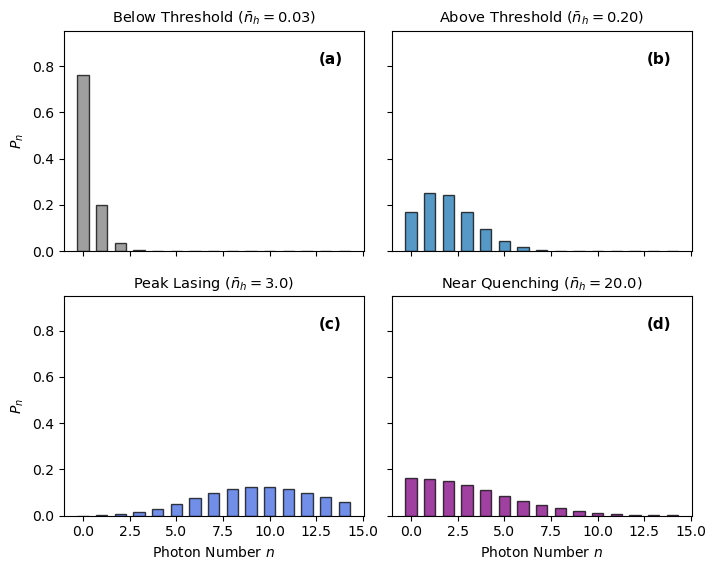

In [ ]:
# ==============================================================================
# FIGURE 3: PHOTON NUMBER DISTRIBUTION P_n IN DIFFERENT REGIMES
# ==============================================================================
def calc_Pn(nh_val, nmax=14):
    """Calculates Pn from the Scully-Lamb recurrence relation for the Lambda-system."""
    Gamma = gamma_h * nh_val + gamma_c * nc
    Phi   = 3.0 * nh_val * nc + nh_val + nc
    Psi   = (gamma_h * (2.0 * nh_val + 1.0) + gamma_c * (2.0 * nc + 1.0)) / (gamma_h * gamma_c)
    A_val = 4.0 * g_coup**2 * nh_val * (nc + 1.0) / (Gamma * Phi)
    Ab_val= 4.0 * g_coup**2 * nc * (nh_val + 1.0) / (Gamma * Phi)
    B_val = A_val * (4.0 * g_coup**2 * Psi) / (Gamma * Phi)

    Pn = np.zeros(nmax + 1)
    Pn[0] = 1.0
    for n in range(1, nmax + 1):
        denom = Ab_val + kappa * (1.0 + n * (B_val / A_val))
        Pn[n] = Pn[n - 1] * (A_val / denom)
    return Pn / np.sum(Pn)

fig3, axes3 = plt.subplots(2, 2, figsize=(7.2, 5.8), sharex=True, sharey=True)

benchmark_nh = [0.03, 0.20, 3.0, 20.0]
regime_labels = [
    r"Below Threshold ($\bar{n}_h = 0.03$)",
    r"Above Threshold ($\bar{n}_h = 0.20$)",
    r"Peak Lasing ($\bar{n}_h = 3.0$)",
    r"Near Quenching ($\bar{n}_h = 20.0$)"
]
panel_tags = ["(a)", "(b)", "(c)", "(d)"]
colors = ["tab:gray", "tab:blue", "royalblue", "purple"]
n_indices = np.arange(15)

for ax_p, nh_val, title, tag, c in zip(axes3.flatten(), benchmark_nh, regime_labels, panel_tags, colors):
    Pn_dist = calc_Pn(nh_val, nmax=14)
    ax_p.bar(n_indices, Pn_dist, color=c, alpha=0.75, edgecolor="black", width=0.6)
    ax_p.set_title(title, fontsize=10.5)
    ax_p.text(0.85, 0.85, tag, transform=ax_p.transAxes, fontweight="bold", fontsize=11)
    ax_p.set_ylim(0, 0.95)

axes3[0, 0].set_ylabel(r"$P_n$")
axes3[1, 0].set_ylabel(r"$P_n$")
axes3[1, 0].set_xlabel(r"Photon Number $n$")
axes3[1, 1].set_xlabel(r"Photon Number $n$")

fig3.tight_layout()
plt.show()